In [1]:
from qiskit import *

# Definitions of the carry, carry inverse, and sum gates
#Carry converted to a custom gate
car = QuantumCircuit(4, name = 'Carry')
car.ccx(1,2,3)
car.cx(1,2)
car.ccx(0,2,3)
carry_gate = car.to_gate()

#Carry Inverse converted to a custom gate
carry_inv = QuantumCircuit(4, name = 'Carry Inverse')
carry_inv.ccx(0,2,3)
carry_inv.cx(1,2)
carry_inv.ccx(1,2,3)
car_inv_gate = carry_inv.to_gate()

#Sum converted to a custom gate
sum = QuantumCircuit(3, name = 'Sum')
sum.cx(1,2)
sum.cx(0,2)
sum_gate = sum.to_gate()

In [2]:
# Definition of the Addition Gate, if control = TRUE, the gate will be controlled by one qubit
def create_add_gate(n:int, control:bool = False):
    A = QuantumRegister(n,"a")
    B = QuantumRegister(n + 1,"b")
    C = QuantumRegister(n,"c")
    
    add = QuantumCircuit(A,B,C, name= 'Add')

    # Subcircuit U_1 with a cascade of carry gates
    for qubit in range(n - 1):
        add.append(carry_gate,[C[qubit], A[qubit], B[qubit], C[qubit + 1]])

    # Subcircuit U_2
    add.append(carry_gate,[C[n-1], A[n-1],B[n-1],B[n]])
    add.cx(A[n-1], B[n-1])
    add.append(sum_gate,[C[n-1], A[n-1], B[n-1]])

    # Subcircuit U_3 with a cascade of sums and carry inverses
    for qubit in range(n - 1)[::-1]:
        add.append(car_inv_gate,[C[qubit],A[qubit],B[qubit],C[qubit+1]])
        add.append(sum_gate,[C[qubit], A[qubit], B[qubit]])
        
    if control:
      return add.to_gate().control(1) # Build a controlled Add gate if control = True
    else:
      return add.to_gate()  # Otherwise build an Add gate
       

In [3]:
# Definition of the Subtraction Gate, if control = TRUE, the gate will be controlled by one qubit
def create_subtraction_gate(n:int, control:bool = False):
    A = QuantumRegister(n,"a")
    B = QuantumRegister(n + 1,"b")
    C = QuantumRegister(n,"c")

    sub = QuantumCircuit(A,B,C, name= 'Subtract')

    # Subcircuit U_3* with a cascade of sum and carry gates
    for qubit in range(n - 1):
        sub.append(sum_gate,[C[qubit], A[qubit], B[qubit]])
        sub.append(carry_gate,[C[qubit], A[qubit], B[qubit], C[qubit + 1]])

    # Subcircuit U_2*
    sub.append(sum_gate,[C[n-1], A[n-1], B[n-1]])    
    sub.cx(A[n-1], B[n-1])
    sub.append(car_inv_gate,[C[n-1], A[n-1], B[n-1], B[n]])    

    # Subcircuit U_1* with a cascade of carry inverses
    for qubit in range(n - 1)[::-1]:
        sub.append(car_inv_gate,[C[qubit], A[qubit], B[qubit], C[qubit + 1]])
        
    if control:
        return sub.to_gate().control(1) # Build a controlled Sub gate if control = True
    else:
        return sub.to_gate() # Otherwise, build a Sub gate

In [4]:
# Definition of the LeftShift gate
# Normally, we need a temporary register to implement a left shift, but since a_n = 0 before the call to this
# gate, we will only swap the qubits of register a
def create_leftshift_gate(n:int):
    areg = n
    leftshift = QuantumCircuit(n, name= 'LeftShift')

#to apply the swap gates
    for qubit in range(1, n)[::-1]:
      leftshift.swap(qubit, qubit - 1)

    return leftshift.to_gate()    

In [5]:
# Definition of the RightShift gate
# Normally, we need a temporary register to implement a right shit, but since a_n = 0 before the call to this
# gate, we will only swap the qubits of register a
def create_rightshift_gate(n:int):
    areg = n
    rightshift = QuantumCircuit(n, name= 'RightShift')

#to apply the swap gates
    for qubit in range(n - 1):
      rightshift.swap(qubit, qubit + 1)

    return rightshift.to_gate()

In [6]:
# Definition of the AddMod gate
# If control = True, the gate will be controlled by one qubit
def create_addmod_gate(n:int, control:bool = False):
    temp_flag = False
    A = QuantumRegister(n,"a")
    B = QuantumRegister(n + 1,"b")
    M = QuantumRegister(n,"Mod")
    T = QuantumRegister(1,"t")
    C = QuantumRegister(n,"c")

    addmod = QuantumCircuit(A,B,M,T,C, name = 'AddMod M')

    # Create the Add, Controlled Add, and Sub gates:
    AddGate = create_add_gate(n, temp_flag)
    temp_flag = True
    CtlAddGate = create_add_gate(n, temp_flag)
    SubGate = create_subtraction_gate(n)

    addmod.append(AddGate,A[:]+B[:]+C[:]) # First sum A + B and save it in B
    addmod.append(SubGate,M[:]+B[:]+C[:]) # Subtract M from B
    addmod.cx(B[n],T) # Toggle T when underflow
    addmod.append(CtlAddGate,T[:]+M[:]+B[:]+C[:]) # When underflow, add M back to B
    addmod.append(SubGate,A[:]+B[:]+C[:]) # Subtract A froM B again
    addmod.cx(B[n],T, ctrl_state=0) # Toggle T when underflow
    addmod.append(AddGate, A[:]+B[:]+C[:]) # Construct final result

    if control:
        return addmod.to_gate().control(1) # Build a controlled AddMod gate if control = True
    else:
        return addmod.to_gate() # Otherwise, build an AddMod gate

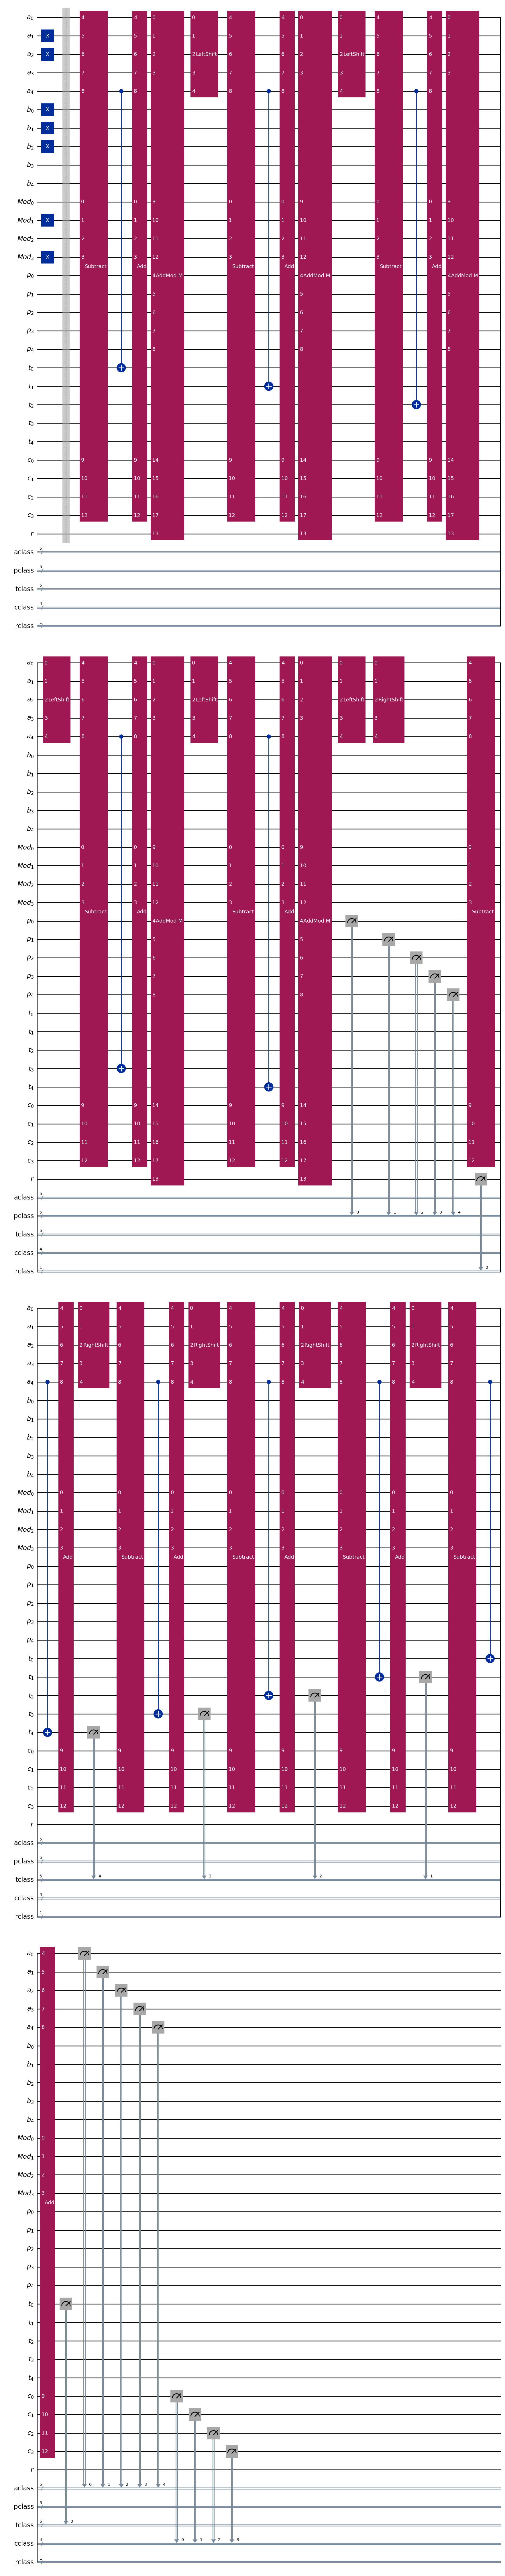

In [7]:
# Create a TimesMod gate:
n = 4
k = 5

A = QuantumRegister(n + 1,"a")
B = QuantumRegister(k,"b")
M = QuantumRegister(n,"Mod")
P = QuantumRegister(n + 1,"p")
T = QuantumRegister(k, "t")
C = QuantumRegister(n,"c")
R = QuantumRegister(1,"r") # extra qubit that will serve as the temporary qubit in all AddMod computations
A_C = ClassicalRegister(n + 1,"aclass") #measurement for output
P_C = ClassicalRegister(n+1,"pclass")
T_C = ClassicalRegister(k, "tclass")
C_C = ClassicalRegister(n,"cclass")
R_C = ClassicalRegister(1,"rclass")

seed_a = '00110' # Value (6) to store in register a
seed_b = '00111' # Value (7) to store in register b
                # Expected product: 6 * 7 mod 10 = 2 = |00010>
seed_m = '1010' # Value (10) of M for arithmetic mod M

TimesModCirc = QuantumCircuit(A,B,M,P,T,C,R,A_C, P_C,T_C, C_C, R_C)

seed_a = list(map(int, list(seed_a)))[::-1] # Rearrange the initial values in reverse order according to Qiskit convention

# encode the value of register a
for bit in range(len(seed_a)):
    if seed_a[bit] == 1:
        TimesModCirc.x(A[bit])
        
# Repeat the process for the initial value of register b
seed_b = list(map(int, list(seed_b)))[::-1] 

# encode the value of register b
for bit in range(len(seed_b)):
    if seed_b[bit] == 1:
        TimesModCirc.x(B[bit])

# Repeat the process for the initial value of register b
seed_m = list(map(int, list(seed_m)))[::-1] 

# encode the value of register b
for bit in range(len(seed_m)):
    if seed_m[bit] == 1:
        TimesModCirc.x(M[bit])

TimesModCirc.barrier()

# Create the gates needed
AddGate = create_add_gate(n)
SubtractGate = create_subtraction_gate(n)
LeftShiftGate = create_leftshift_gate(n + 1)
RightShiftGate = create_rightshift_gate(n + 1)
AddModMGate = create_addmod_gate(n)

control = True

# Create the controlled gates
CtrlAddGate = create_add_gate(n, control)
CtrlSubGate = create_subtraction_gate(n, control)
CtrlAddModGate = create_addmod_gate(n, control)


for i in range(k):
    TimesModCirc.append(SubtractGate,M[:]+A[:]+C[:]) # Subtract M from A
    TimesModCirc.cx(A[n],T[i])  # t_i = 1 if M > a
    TimesModCirc.append(CtrlAddGate,T[i:i+1]+M[:]+A[:]+C[:]) # add M to A if t_i is set
    TimesModCirc.append(CtrlAddModGate, B[i:i+1]+A[0:n]+P[:]+M[:]+R[:]+C[:]) # add a to p if b_i is set
    TimesModCirc.append(LeftShiftGate,A[:]) # Multiply a by 2

for i in range(k)[::-1]:
    TimesModCirc.append(RightShiftGate,A[:]) # Divide a by 2
    TimesModCirc.append(CtrlSubGate, T[i:i+1]+M[:]+A[:]+C[:]) # perform steps in reverse to reset A, T, C, R
    TimesModCirc.cx(A[n],T[i])  
    TimesModCirc.append(AddGate,M[:]+A[:]+C[:]) # add M to A 
    
TimesModCirc.measure(A, A_C) # Confirm that A, T, C, R are reset to original values
TimesModCirc.measure(P, P_C) # Measure the result p = a*b mod M
TimesModCirc.measure(T, T_C)
TimesModCirc.measure(C, C_C)
TimesModCirc.measure(R, R_C)

#draw the circuit.
TimesModCirc.draw(output="mpl")

In [9]:
# Measure the value of t and the carry register in the n + 1 most significant qubits
# and the value of the register b in the n + 1 least significant qubits
# This simulator fails if n > 3, k > 3, due to not enough qubits, so do not use
from qiskit_aer.primitives import SamplerV2
 
sampler = SamplerV2()
job_simulator = sampler.run([TimesModCirc.decompose(reps=6)], shots = 1024)

result_simulator = job_simulator.result()
counts1 = result_simulator[0].data.pclass.get_counts() # First value displayed is a*b mod M
counts2 = result_simulator[0].data.aclass.get_counts() # displaying registers A, T, C, R to make sure they are reset
counts3 = result_simulator[0].data.tclass.get_counts()
counts4 = result_simulator[0].data.cclass.get_counts()
counts5 = result_simulator[0].data.rclass.get_counts()
print(counts1, counts2,counts3,counts4,counts5)

Simulation failed and returned the following error message:
ERROR:  [Experiment 0] Insufficient memory to run circuit circuit-169 using the statevector simulator. Required memory: 8192M, max memory: 8069M


ValueError: could not broadcast input array from shape (0,1) into shape (1024,1)

In [11]:
from qiskit_aer import AerProvider, AerSimulator

# Select the AerSimulator from the Aer provider
# Matrix Product State should allow us to use more qubits in the circuit
simulator = AerSimulator(method='matrix_product_state')

# Run and get counts, using the matrix_product_state method
tcirc = transpile(TimesModCirc, simulator)
result = simulator.run(tcirc).result()
counts = result.get_counts(0)
print(counts)
# The result is displayed in reverse order: R, then C, then T, then P, then A

{'0 0000 00000 00010 00110': 1024}
